## Предсказания TLM для TIMIT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime

In [2]:
file_path = '/home/ext-ivanova-mk@ad.speechpro.com/test_dir/tlm/feature_extraction/timit_titanet_embeddings/timit_titanet_metadata_with_predictions.csv'
SPKRINFO_FILE = "/home/ext-ivanova-mk@ad.speechpro.com/ITMO/darpa-timit-acousticphonetic-continuous-speech/versions/6/SPKRINFO.TXT"

In [3]:
df_preds = pd.read_csv(file_path)

print(f"Загружено {len(df_preds)} записей")
df_preds = df_preds[df_preds['file_path'].str.contains('/TEST/', na=False)]
df_preds.head()

Загружено 6300 записей


,speaker_full,speaker_id,gender,file_name,file_path,embedding_path,age_pred
0,FAKS0,AKS0,F,SA1,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/dar...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,25.854841
1,FAKS0,AKS0,F,SA2,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/dar...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,25.240726
2,FAKS0,AKS0,F,SI1573,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/dar...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,26.000000
3,FAKS0,AKS0,F,SI2203,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/dar...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,24.871278
4,FAKS0,AKS0,F,SI943,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/dar...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,24.315985


In [5]:
def parse_sprkinfo(file_path):
    data = []
    in_data_section = False
    line_num = 0
    
    with open(file_path, 'r') as f:
        for line in f:
            line_num += 1
            line = line.rstrip()
            
            if ';ID  Sex DR Use' in line:
                in_data_section = True
                continue
            
            if line.startswith(';'):
                continue
            
            if line.startswith('--') or not line.strip():
                continue
            
            if in_data_section:
                parts = re.split(r'\s{2,}', line.strip())
                if len(parts) >= 9:
                    row = [p.strip() for p in parts[:9]]
                    if len(parts) > 9:
                        row.append(' '.join(parts[9:]).strip())
                    else:
                        row.append('')
                    data.append(row)
    
    columns = ['ID', 'Sex', 'DR', 'Use', 'RecDate', 'BirthDate', 'Ht', 'Race', 'Edu', 'Comments']
    return pd.DataFrame(data, columns=columns)

df_speakers = parse_sprkinfo(SPKRINFO_FILE)
print(f"Загружено {len(df_speakers)} записей о дикторах")
df_speakers.head()

Загружено 630 записей о дикторах


,ID,Sex,DR,Use,RecDate,BirthDate,Ht,Race,Edu,Comments
0,ABC0,M,6,TRN,03/03/86,06/17/60,"5'11""",WHT,BS,
1,ABW0,M,2,TST,04/21/86,05/26/59,"5'9""",WHT,BS,
2,ADC0,M,3,TRN,02/25/86,04/27/54,"5'9""",WHT,HS,
3,ADD0,M,7,TRN,01/28/86,03/23/58,"6'2""",WHT,BS,
4,ADG0,F,4,TST,02/12/86,04/11/59,"5'4""",WHT,MS,


In [6]:
df_speakers = df_speakers[~df_speakers['BirthDate'].str.contains('\?\?', na=False)]

df_speakers['BirthDate_dt'] = pd.to_datetime(df_speakers['BirthDate'], format='%m/%d/%y')
df_speakers['RecDate_dt'] = pd.to_datetime(df_speakers['RecDate'], format='%m/%d/%y')

mask_wrong_century = df_speakers['BirthDate_dt'] > df_speakers['RecDate_dt']
df_speakers.loc[mask_wrong_century, 'BirthDate_dt'] = df_speakers.loc[mask_wrong_century, 'BirthDate_dt'] - pd.DateOffset(years=100)

df_speakers['Age'] = (df_speakers['RecDate_dt'] - df_speakers['BirthDate_dt']).dt.days / 365.25

speaker_to_age = dict(zip(df_speakers['ID'], df_speakers['Age']))

In [7]:
df_speakers.head()

,ID,Sex,DR,Use,RecDate,BirthDate,Ht,Race,Edu,Comments,BirthDate_dt,RecDate_dt,Age
0,ABC0,M,6,TRN,03/03/86,06/17/60,"5'11""",WHT,BS,,1960-06-17,1986-03-03,25.708419
1,ABW0,M,2,TST,04/21/86,05/26/59,"5'9""",WHT,BS,,1959-05-26,1986-04-21,26.904860
2,ADC0,M,3,TRN,02/25/86,04/27/54,"5'9""",WHT,HS,,1954-04-27,1986-02-25,31.832991
3,ADD0,M,7,TRN,01/28/86,03/23/58,"6'2""",WHT,BS,,1958-03-23,1986-01-28,27.852156
4,ADG0,F,4,TST,02/12/86,04/11/59,"5'4""",WHT,MS,,1959-04-11,1986-02-12,26.841889


In [8]:
def extract_speaker_id(file_path):
    parts = file_path.split('/')
    
    for part in parts:
        if len(part) == 5 and part[0] in ['F', 'M']:
            return part[1:]
    
    return None

In [9]:
# Добавляем истинный возраст к предсказаниям
df_preds['speaker_id'] = df_preds['file_path'].apply(extract_speaker_id)
df_preds['true_age'] = df_preds['speaker_id'].map(speaker_to_age)

# Удаляем строки, для которых не нашли возраст
df_preds = df_preds.dropna(subset=['true_age'])
print(f"Обработано {len(df_preds)} записей с истинными метками")
df_preds.head()

Обработано 1680 записей с истинными метками


,speaker_full,speaker_id,gender,file_name,file_path,embedding_path,age_pred,true_age
0,FAKS0,AKS0,F,SA1,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/dar...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,25.854841,28.320329
1,FAKS0,AKS0,F,SA2,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/dar...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,25.240726,28.320329
2,FAKS0,AKS0,F,SI1573,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/dar...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,26.000000,28.320329
3,FAKS0,AKS0,F,SI2203,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/dar...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,24.871278,28.320329
4,FAKS0,AKS0,F,SI943,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/dar...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,24.315985,28.320329


In [10]:
# Вычисление ошибок
df_preds['error'] = df_preds['age_pred'] - df_preds['true_age']
df_preds['abs_error'] = abs(df_preds['error'])
df_preds['squared_error'] = df_preds['error'] ** 2

# Основные метрики
MAE = df_preds['abs_error'].mean()
RMSE = np.sqrt(df_preds['squared_error'].mean())
STD_ERROR = df_preds['error'].std()

# Процент ошибок в пределах
within_1_year = (df_preds['abs_error'] <= 1).mean() * 100
within_3_years = (df_preds['abs_error'] <= 3).mean() * 100
within_5_years = (df_preds['abs_error'] <= 5).mean() * 100
within_10_years = (df_preds['abs_error'] <= 10).mean() * 100

print("Метрики оценки TLM модели")
print("\nОсновные метрики:")
print(f"MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")

print("\nПроцент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_3_years:.1f}%")
print(f"  ≤ 5 лет:   {within_5_years:.1f}%")
print(f"  ≤ 10 лет:   {within_10_years:.1f}%")

print("\nСтатистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df_preds['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df_preds['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df_preds['abs_error'].max():.3f} лет")

Метрики оценки TLM модели

Основные метрики:
MAE  (Mean Absolute Error):     4.360 лет
RMSE (Root Mean Squared Error): 6.356 лет
Std of Error (разброс ошибок):  5.972 лет

Процент ошибок в пределах:
  ≤ 1 год:   17.7%
  ≤ 3 года:  52.5%
  ≤ 5 лет:   70.5%
  ≤ 10 лет:   90.0%

Статистика абсолютных ошибок:
  Мин ошибка:  0.001 лет
  Медиана:     2.836 лет
  Макс ошибка: 34.348 лет


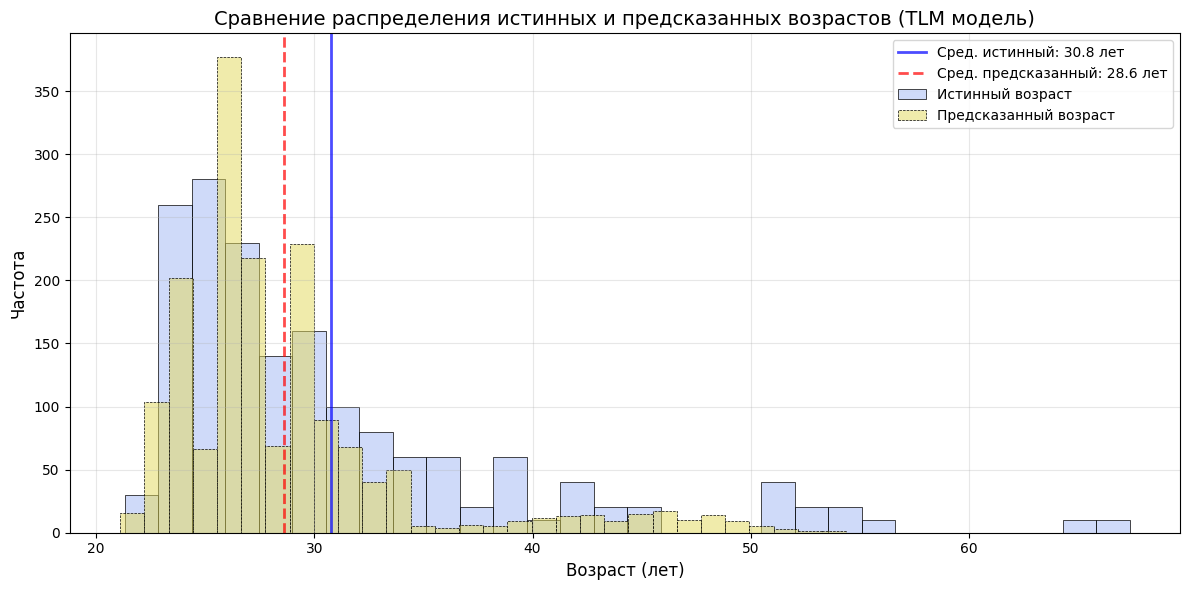

In [11]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_preds, x='true_age', bins=30, 
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5)
sns.histplot(data=df_preds, x='age_pred', bins=30, 
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, linestyle='--')

plt.axvline(df_preds['true_age'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df_preds["true_age"].mean():.1f} лет')
plt.axvline(df_preds['age_pred'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df_preds["age_pred"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов (TLM модель)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()